#Introducción: Descripción del problema y objetivo del modelo

Para este proyecto práctico, abordaremos un problema de clasificación de imágenes de prendas de vestir utilizando el reconocido dataset Fashion-MNIST.

El dataset está compuesto por 70.000 imágenes en escala de grises con una resolución estandarizada de 28x28 píxeles. Estas imágenes se dividen en 60.000 muestras para el entrenamiento del modelo y 10.000 muestras exclusivas para la prueba y validación. El objetivo predictivo cuenta con 10 categorías distintas , que incluyen prendas como camisetas, pantalones, suéteres, vestidos, abrigos y distintos tipos de calzado y accesorios.

el proyecto tiene como objetivo principal implementar una Red Neuronal Artificial del tipo CNN para la solución de este problema de clasificación multiclase.

#Carga de datos

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



(imgs_train,labs_train), (imgs_test,labs_test) = fashion_mnist.load_data()
print(imgs_train.shape)
print(imgs_test.shape)
nombres = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


En esta sección se inicializa el entorno de trabajo y se preparan los datos para la red neuronal:

Librerías: Se cargan tensorflow.keras, numpy, pandas y matplotlib. Estas son esenciales para construir el modelo, manipular arreglos numéricos y visualizar resultados.

Carga del Dataset: Se utiliza fashion_mnist.load_data() para obtener el conjunto de datos de entrenamiento (60,000 imágenes) y prueba (10,000 imágenes) de 28x28 píxeles.

Definición de Etiquetas: Se crea una lista llamada nombres que mapea los índices numéricos a categorías de ropa legibles (ej: 'Camiseta/Top', 'Bolso', 'Botín').

# Visualizacion

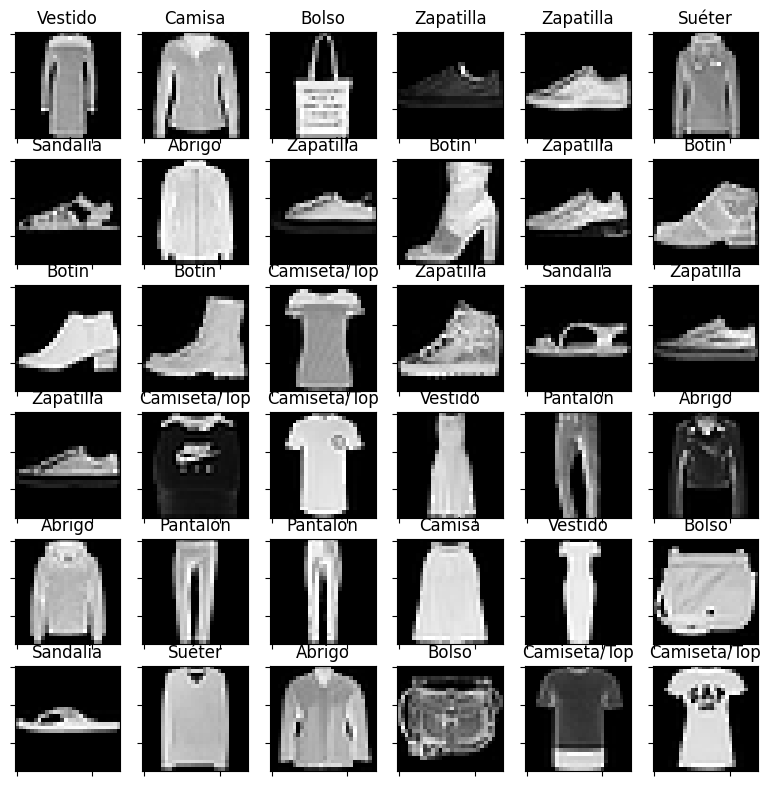

In [ ]:
h = 6 # alto de la grilla
w = 6 # ancho de la grilla
fig, axs = plt.subplots(h, w, figsize=(1.6*h,1.6*w))
for i in range(h):
  for j in range(w):
    ex = np.random.randint(len(imgs_test))
    axs[i,j].set_title(nombres[labs_test[ex]])
    axs[i,j].grid(False)
    axs[i,j].set_xticklabels([])
    axs[i,j].set_yticklabels([])
    axs[i,j].imshow(imgs_test[ex], cmap='gray')

Aqui se crea una cuadrícula de 6x6 (36 imágenes) usando plt.subplots.

 Ademas, se utiliza np.random.randint para seleccionar imágenes al azar del set de prueba, mostrando la imagen en escala de grises (cmap='gray') y asignando su etiqueta correspondiente como título. Esto permite validar visualmente que los datos se cargaron correctamente.

#Validacion de datos

In [ ]:
import numpy as np
print(f"\n1. Dimensiones:")
print(f"   Imágenes de entrenamiento: {imgs_train.shape} ({imgs_train.shape[0]} muestras de {imgs_train.shape[1]}x{imgs_train.shape[2]} píxeles)")
print(f"   Imágenes de prueba:        {imgs_test.shape} ({imgs_test.shape[0]} muestras de {imgs_test.shape[1]}x{imgs_test.shape[2]} píxeles)")
print(f"   Etiquetas de entrenamiento:{labs_train.shape}")
print(f"   Etiquetas de prueba:       {labs_test.shape}")

print(f"\n2. Búsqueda de valores nulos:")
nulos_train = np.isnan(imgs_train).sum()
nulos_test = np.isnan(imgs_test).sum()
if nulos_train == 0 and nulos_test == 0:
    print("Dataset limpio")
else:
    print(f"Se encontraron {nulos_train} nulos en train y {nulos_test} en test")


print(f"\n3. Rango de píxeles original (debe ser de 0 a 255):")
print(f"   Set Entrenamiento -> Mínimo: {imgs_train.min()} | Máximo: {imgs_train.max()}")
print(f"   Set Prueba        -> Mínimo: {imgs_test.min()} | Máximo: {imgs_test.max()}")


print(f"\n4. Clases objetivo (Labels):")
clases_unicas = np.unique(labs_train)
conteo_clases = np.bincount(labs_train)
print(f"   Categorías identificadas: {len(clases_unicas)} clases (Del {clases_unicas.min()} al {clases_unicas.max()})")
print("   Distribución de imágenes por clase en el set de entrenamiento:")
for clase, cantidad in zip(clases_unicas, conteo_clases):
    print(f"      - Clase {clase}: {cantidad} imágenes")


1. Dimensiones:
   Imágenes de entrenamiento: (60000, 28, 28) (60000 muestras de 28x28 píxeles)
   Imágenes de prueba:        (10000, 28, 28) (10000 muestras de 28x28 píxeles)
   Etiquetas de entrenamiento:(60000,)
   Etiquetas de prueba:       (10000,)

2. Búsqueda de valores nulos:
Dataset limpio

3. Rango de píxeles original (debe ser de 0 a 255):
   Set Entrenamiento -> Mínimo: 0 | Máximo: 255
   Set Prueba        -> Mínimo: 0 | Máximo: 255

4. Clases objetivo (Labels):
   Categorías identificadas: 10 clases (Del 0 al 9)
   Distribución de imágenes por clase en el set de entrenamiento:
      - Clase 0: 6000 imágenes
      - Clase 1: 6000 imágenes
      - Clase 2: 6000 imágenes
      - Clase 3: 6000 imágenes
      - Clase 4: 6000 imágenes
      - Clase 5: 6000 imágenes
      - Clase 6: 6000 imágenes
      - Clase 7: 6000 imágenes
      - Clase 8: 6000 imágenes
      - Clase 9: 6000 imágenes


Antes de comenzar a entrenar el modelo, hicimos una revisión rápida pero exhaustiva del dataset Fashion-MNIST utilizando NumPy llegando a las siguientes conclusiones:


-Estructura correcta: Confirmamos que tenemos exactamente las 60.000     imágenes para entrenar y 10.000 para probar, todas con la resolución esperada de 28x28 píxeles

-Cero datos corruptos: Comprobamos que no hubiera ningún valor vacío o nulo  que pudiera romper el código más adelante. Además, verificamos que la intensidad de los píxeles estuviera en su rango normal de 0 a 255.

-Verificamos que cada una de las 10 categorías de ropa tiene exactamente 6.000 imágenes de ejemplo. Al tener un dataset tan bien balanceado, nos aseguramos de que la red neuronal no genere un sesgo o preferencia hacia ninguna prenda en particular


# division datos train y test junto a transformacion a vector

In [ ]:
# Tranformamos los datos para el entrenamiento,
# Necesitamos transformar tanto el train como el test

X_train = imgs_train.reshape(-1, 28, 28, 1)
X_test = imgs_test.reshape(-1, 28, 28, 1)
X_train = X_train / 255
X_test = X_test / 255
print('X', X_train.shape, X_test.shape)

Y_train = keras.utils.to_categorical(labs_train, 10)
Y_test = keras.utils.to_categorical(labs_test, 10)
print('Y', Y_train.shape, Y_test.shape)

X (60000, 28, 28, 1) (10000, 28, 28, 1)
Y (60000, 10) (10000, 10)


Este modulo de código ejecuta la fase de preparación y transformación de de los datos de entrenamiento requerida, donde en primer lugar se utiliza la función reshape(-1, 28, 28, 1) para adaptar las imágenes bidimensionales nativas a la estructura de cuatro dimensiones exigida, las CNN requieren que los datos de entrenamiento estén organizados específicamente en estas dimensiones: (Tamaño del lote, Altura, Ancho, Canales), especificando una profundidad de 1 debido a que se trabaja en escala de grises. Posteriormente, se realiza una normalización al dividir los píxeles por de 0 a 255, transformando los valores, lo cual es fundamental para garantizar la estabilidad que evita que algunas dimensiones sean interpretadas como más importantes que otras. Esto permite que la función de costo se minimice de forma más rápida y directa, logrando un entrenamiento más efectivo mejorando la convergencia del optimizador hacia el mínimo de la función de pérdida. Finalmente, las etiquetas categóricas se transforman mediante a vectores binarios (One-Hot Encoding) de longitud 10 para evitar que la red interprete relaciones de orden erróneas entre clases

#funcion resumen de modelo

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def post_entrenamiento(modelo_entrenado, historia, x_prueba, y_prueba, nombre_experimento="modelo"):

    # 1. GUARDADO AUTOMÁTICO
    archivo_keras = f"{nombre_experimento}.keras"
    modelo_entrenado.save(archivo_keras)
    print(f"\n¡Modelo guardado exitosamente como '{archivo_keras}'!\n")

    # 2. EXTRACCIÓN DE RESULTADOS EXACTOS (Última época)
    acc_final = historia.history['accuracy'][-1]
    loss_final = historia.history['loss'][-1]
    val_acc_final = historia.history['val_accuracy'][-1]
    val_loss_final = historia.history['val_loss'][-1]

    print("="*50)
    print(f"RESULTADOS FINALES: {nombre_experimento}")
    print("="*50)
    print(f"Loss Train : {loss_final:.4f}  |  Accuracy Train : {acc_final:.4f}")
    print(f"Loss Val   : {val_loss_final:.4f}  |  Accuracy Val   : {val_acc_final:.4f}")
    print("="*50 + "\n")

    # 3. PREDICCIONES Y REPORTE
    predicciones = modelo_entrenado.predict(x_prueba)
    y_pred_classes = np.argmax(predicciones, axis=1)

    # Manejo de formato de etiquetas
    if len(y_prueba.shape) > 1:
        y_true_classes = np.argmax(y_prueba, axis=1)
    else:
        y_true_classes = y_prueba

    class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
                   'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

    print("--- REPORTE DE CLASIFICACIÓN AVANZADA ---")
    print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

    # 4. GRÁFICOS COMPACTOS (Todo en una sola fila)
    fig = plt.figure(figsize=(18, 5))

    # Matriz
    ax1 = plt.subplot(1, 3, 1)
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title('Matriz de Confusión')
    ax1.set_ylabel('Realidad')
    ax1.set_xlabel('Predicción')

    # Loss
    ax2 = plt.subplot(1, 3, 2)
    ax2.plot(historia.history['loss'], label='Train Loss', color='blue')
    ax2.plot(historia.history['val_loss'], label='Val Loss', color='orange')
    ax2.set_title('Curva de Pérdida (Loss)')
    ax2.set_xlabel('Época')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    # Accuracy
    ax3 = plt.subplot(1, 3, 3)
    ax3.plot(historia.history['accuracy'], label='Train Acc', color='blue')
    ax3.plot(historia.history['val_accuracy'], label='Val Acc', color='orange')
    ax3.set_title('Curva de Precisión (Accuracy)')
    ax3.set_xlabel('Época')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

Este bloque de código crea una herramienta automática en este caso post_entrenamiento. Entrenar una red neuronal es caro computacionalmente y consume tiempo, guardando los parámetros finales permite reutilizar el modelo para hacer predicciones en el futuro sin tener que repetir el proceso de encontrar los valores óptimos de los pesos y pueda ser usada en el futuro. Tambien imprime los valores finales de Pérdida (Loss) y Precisión (Accuracy) alcanzados en la última época tanto para el conjunto de entrenamiento como para el de validación esto nos permiten saber rápidamente si el entrenamiento fue consistente

Posteriormente se usa el modelo para predecir etiquetas en datos que nunca ha visto (x_prueba) y genera un reporte detallado con nombres de estas clases, lo que nos permite saber su desempeño a la hora de generalizar con datos nuevos

Para analizar estos resultados se generan tres gráficos clave: un mapa visual (Matriz de Confusión) que dice cuales clases el modelo resulta dificil de clasificarlas, y por ultimo realiza la grafica de Perdida y Precision, para ver su desempeño a lo largo de todas sus epocas

# Modelo 1: CNN Base con Optimizador SGD

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento del Modelo 1...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.5880 - loss: 1.1794 - val_accuracy: 0.7166 - val_loss: 0.7311
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.7416 - loss: 0.6936 - val_accuracy: 0.7657 - val_loss: 0.6337
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.7746 - loss: 0.5980 - val_accuracy: 0.7679 - val_loss: 0.6010
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.7977 - loss: 0.5453 - val_accuracy: 0.8008 - val_loss: 0.5327
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.8126 - loss: 0.5084 - val_accuracy: 0.8188 - val_loss: 0.4953
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.8256 - loss: 0.4782 - val_accuracy: 0.8305 - val_loss: 0.4738
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.8345 - loss: 0.4557 - val_accuracy: 0.8336 - val_loss: 0.4559
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/s

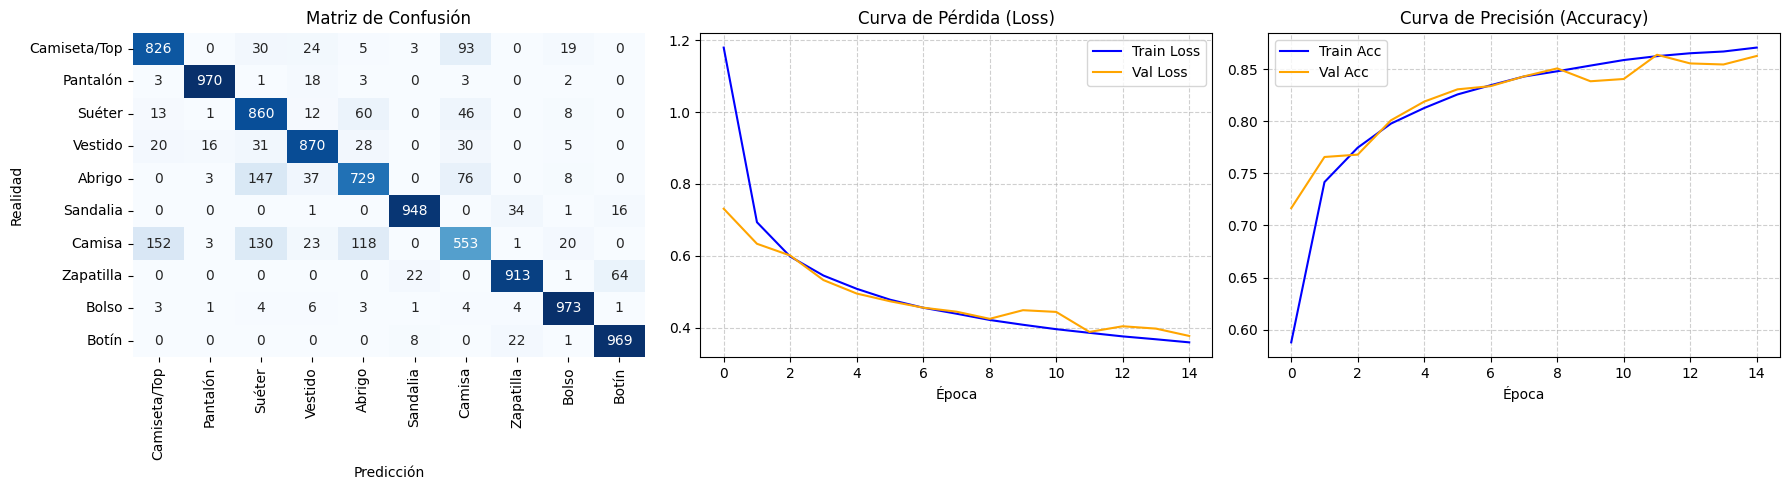

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import SGD

# 1. ARQUITECTURA A LA VISTA
modelo_1 = models.Sequential()
modelo_1.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
modelo_1.add(layers.MaxPooling2D((2, 2)))
modelo_1.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_1.add(layers.MaxPooling2D((2, 2)))
modelo_1.add(layers.Flatten())
modelo_1.add(layers.Dense(64, activation='relu'))
modelo_1.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN
modelo_1.compile(optimizer=SGD(learning_rate=0.01),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. ENTRENAMIENTO EXPLÍCITO
print("Iniciando entrenamiento del Modelo 1...")
historia_1 = modelo_1.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=15,
                          validation_split=0.2,
                          verbose=1)

# 4. DELEGAR POST-ENTRENAMIENTO A LA FUNCIÓN
post_entrenamiento(modelo_1, historia_1, X_test, Y_test, nombre_experimento="Modelo_1_SGD")

Este bloque de código define la estructura y el entrenamiento del Modelo 1, que sirve como la base de los sigueintes experimentos utilizando una arquitectura convolucional clásica (CNN). El modelo se construye de forma secuencial agregando capas Conv2D con funciones de activación ReLU para extraer características visuales esenciales, combinadas con capas MaxPooling2D que reducen el tamaño de las imágenes para quedarse solo con la información más importante. Posteriormente, se utiliza la capa Flatten para transformar los mapas de características bidimensionales en un vector de una sola dimensión, permitiendo que la capa oculta (Dense) procese los datos y los entregue a la capa de salida, la cual utiliza la función Softmax con 10 neuronas para calcular la probabilidad de pertenencia a cada clase de ropa. Para el proceso de aprendizaje, se configura el optimizador SGD (Descenso de Gradiente Estocástico) con una tasa de aprendizaje de 0.01 y la función de pérdida categorica. Finalmente, el modelo se entrena durante 15 épocas con un tamaño de lote (batch size) de 64, reservando un 20% de los datos para validación con el fin de monitorear el rendimiento en cada vuelta, detectar posibles inestabilidades, y pasar los resultados automáticamente a la función de diagnóstico, tambien se usaron la cantidad de filtros de 32 y 64 de 3x3 en las distintas capas

# **Resultados: Modelo 1 (CNN Base con Optimizador SGD)**

1. Análisis de las Curvas de Aprendizaje

Al analizar el comportamiento del entrenamiento, la Curva de Pérdida (Loss) y la Curva de Precisión (Accuracy) muestran una constante inestabilidad y pequeñas oscilaciones (subidas y bajadas bruscas) a lo largo de las 15 épocas, manifestándose con mayor fuerza en la trayectoria de validación (línea naranja). Esta inestabilidad se debe directamente a la naturaleza del optimizador SGD (Descenso de Gradiente Estocástico) con una tasa de aprendizaje fija de 0.01. Al no ser algo adaptativo, SGD actualiza los pesos basándose puramente en la dirección del gradiente de cada lote individual, lo que provoca que el modelo dé saltos toscos en las curvas en lugar de avanzar de forma suave. A pesar de este andar inestable, ambas curvas progresan de forma paralela sin abrir una brecha significativa entre ellas, esto confirma que el modelo avanza lento pero seguro, sin presentar problemas graves de sobreajuste (overfitting), logrando una precisión final en validación cercana al 85%.

2. Análisis de la Matriz de Confusión e Inferencia

La matriz de confusión revela que el Modelo 1 alcanza un desempeño notable en categorías con siluetas muy marcadas y únicas, logrando altos niveles de acierto en Pantalón (961), Bolso (957) y Zapatilla (939). Sin embargo, el principal punto débil del modelo se concentra en las prendas superiores debido a una severa confusión entre clases, la categoría Camisa es la que presenta el desempeño más bajo (solo 568 aciertos), confundiéndose masivamente con Camiseta/Top (159 veces), Abrigo (112 veces) y Suéter (110 veces). Esta dificultad para discriminar detalles finos en cuellos y mangas se traduce en un bajo valor de Recall para la Camisa, lo que demuestra que esta configuración base está generalizando mal ante categorías complejas que comparten características visuales muy similares.

# Modelo 2: CNN base con optimizador adam

Iniciando entrenamiento del Modelo 2 (Prueba de Velocidad con Adam)...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.8067 - loss: 0.5411 - val_accuracy: 0.8563 - val_loss: 0.3888
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8735 - loss: 0.3524 - val_accuracy: 0.8717 - val_loss: 0.3543
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.8876 - loss: 0.3068 - val_accuracy: 0.8860 - val_loss: 0.3133
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.8999 - loss: 0.2757 - val_accuracy: 0.8997 - val_loss: 0.2784
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9074 - loss: 0.2526 - val_accuracy: 0.8960 - val_loss: 0.2842
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9153 - loss: 0.2311 - val_accuracy: 0.9048 - val_loss: 0.2631
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.9215 - loss: 0.2125 - val_accuracy: 0.8956 - val_loss: 0.2827
Epoch 8/15
750/750 

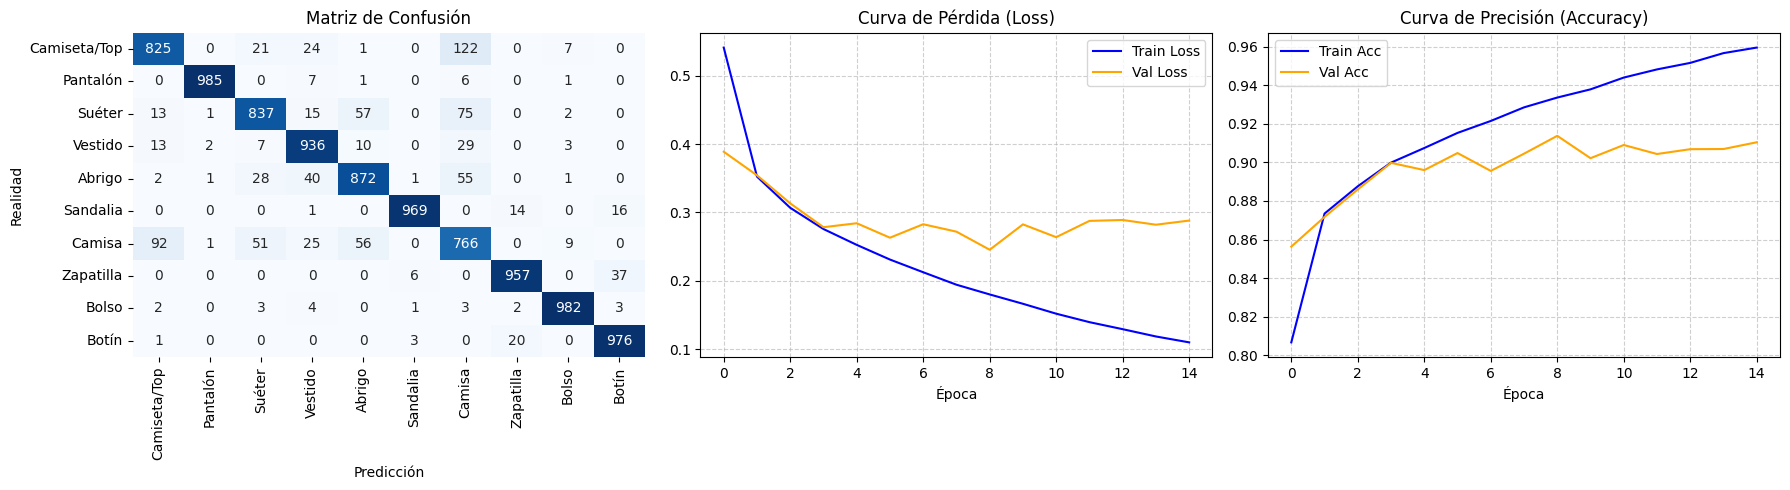

In [ ]:
from tensorflow.keras.optimizers import Adam

# 1. ARQUITECTURA (Idéntica al Modelo 1 para aislar la variable)
modelo_2 = models.Sequential()
modelo_2.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
modelo_2.add(layers.MaxPooling2D((2, 2)))
modelo_2.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_2.add(layers.MaxPooling2D((2, 2)))
modelo_2.add(layers.Flatten())
modelo_2.add(layers.Dense(64, activation='relu'))
modelo_2.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN
modelo_2.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. ENTRENAMIENTO EXPLÍCITO (Mismas 15 épocas)
print("Iniciando entrenamiento del Modelo 2 (Prueba de Velocidad con Adam)...")
historia_2 = modelo_2.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=15,
                          validation_split=0.2,
                          verbose=1)

# 4. EVALUACIÓN Y GRÁFICOS
post_entrenamiento(modelo_2, historia_2, X_test, Y_test, nombre_experimento="Modelo_2_Adam")

en este modulo se define y entrena el Modelo 2, Para garantizar un análisis comparativo válido frente al experimento anterior, se mantiene exactamente la misma arquitectura secuencial (capas Conv2D de 32 y 64 filtros de 3x3, seguidas de reducciones con MaxPooling2D y capas densas con activación ReLU y Softmax). La única variable modificada se encuentra en la etapa de compilación, donde se sustituye el optimizador básico por Adam con una tasa de aprendizaje estándar de 0.001. A diferencia de SGD, Adam ajusta dinámicamente la tasa de aprendizaje para cada parámetro, utilizando el promedio de los gradientes históricos (media y varianza), lo que suele acelerar la convergencia para ajustar de manera independiente la velocidad de aprendizaje de cada parámetro. Finalmente, el modelo ejecuta su entrenamiento bajo las mismas condiciones de entorno que el experimento 1 (15 épocas y lotes de 64), lo que nos permite evaluar a través de la función de diagnóstico si este cambio mitiga las oscilaciones y la inestabilidad en las curvas de pérdida, acelerando la convergencia sin caer en un sobreajuste temprano.

# **Resultados: Modelo 2 (CNN Base con Optimizador Adam)**

1. Análisis de las Curvas de Aprendizaje

El comportamiento de las curvas del Modelo 2 muestra un cambio drástico debido a la incorporación de Adam como optimizador. En este experimento se observa una aceleración en la velocidad de aprendizaje, la curva de precisión en entrenamiento sube rápidamente por encima del 95% y su pérdida cae de forma abrupta hacia cero. A pesar de esto, la velocidad sacrificó por completo la estabilidad, la trayectoria de validación presenta oscilaciones aun mayores,  agresivas e inestables, especialmente a partir de la época 4, donde la pérdida de validación sube hacia arriba irregularmente. Esta inestabilidad ocurre porque Adam calcula tasas de aprendizaje adaptativas para cada parámetro, al no contar con ninguna capa de regularización en este modelo, el optimizador avanza de forma tan veloz y agresiva que "supera" los puntos óptimos. Esto abre una brecha y creciente entre las curvas de entrenamiento y validación, un síntoma  de un sobreajuste (overfitting), donde el modelo se aprendió de memoria los datos de práctica.

2. Análisis de la Matriz de Confusión e Inferencia

A pesar del sobreajuste visible en las curvas, la matriz de confusión muestra que el cambio a un optimizador adaptativo mejoró el rendimiento de clasificacion general frente al experimento anterior. El Modelo 2 incrementó de forma notable los aciertos en casi todas las categorías, logrando rescatar la prenda más crítica, la Camisa subió de 568 a 691 aciertos. Esto demuestra que la eficiencia de Adam ayudó a la red a detectar patrones visuales más complejos para discriminar ropa superior. Sin embargo, el problema a pesar de esto no se ha solucionado , la Camisa mantiene su confusión característica con Camiseta/Top (114 veces) y Abrigo (107 veces). Este comportamiento residual confirma que el modelo sigue arrastrando problemas para generalizar limpiamente en fronteras difusas, capturando el ruido del set de entrenamiento.

# Modelo 3: CNN optimizador adam con dropout

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento del Modelo 3 (Adam + Dropout)...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 55s 71ms/step - accuracy: 0.7205 - loss: 0.7753 - val_accuracy: 0.8339 - val_loss: 0.4575
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.8082 - loss: 0.5270 - val_accuracy: 0.8599 - val_loss: 0.3822
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8319 - loss: 0.4652 - val_accuracy: 0.8704 - val_loss: 0.3514
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8455 - loss: 0.4223 - val_accuracy: 0.8811 - val_loss: 0.3230
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8580 - loss: 0.3927 - val_accuracy: 0.8898 - val_loss: 0.3033
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.8668 - loss: 0.3683 - val_accuracy: 0.8920 - val_loss: 0.2930
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.8727 - loss: 0.3456 - val_accuracy: 0.8952 - val_loss: 0.2897
Epoch 8/15
750/750 ━━━━━━━━━━━━━━

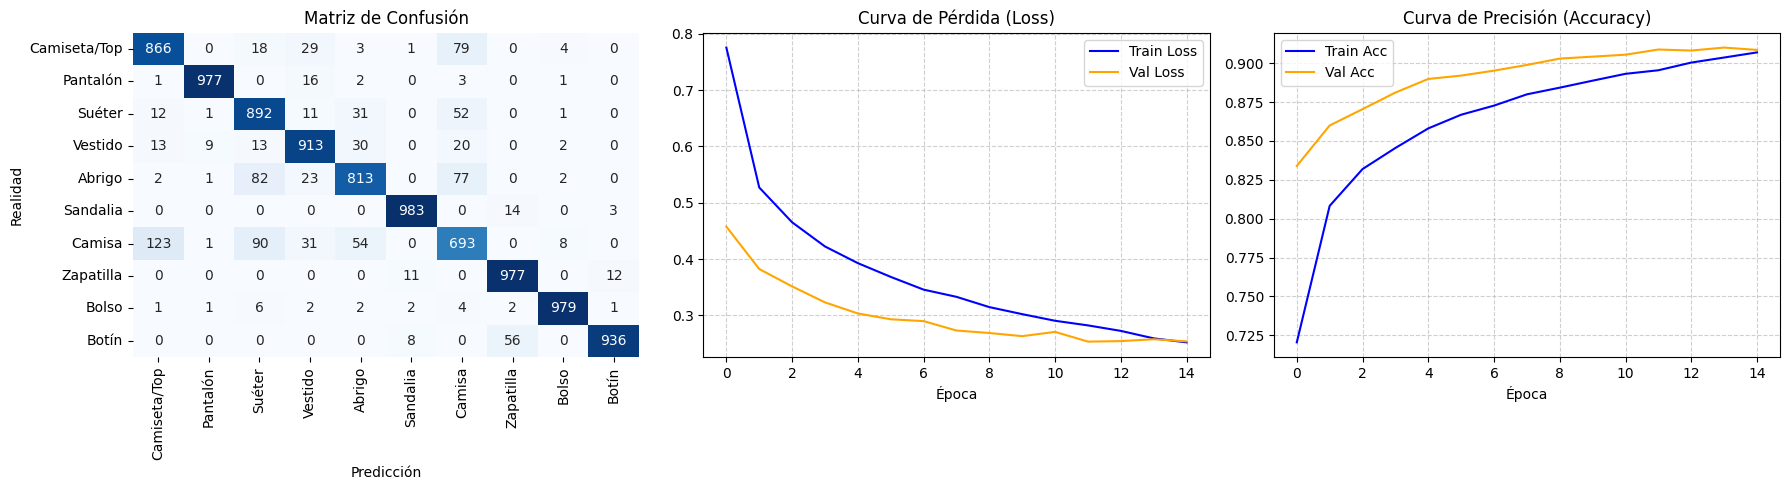

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models

# 1. ARQUITECTURA CON REGULARIZACIÓN (Dropout)
modelo_3 = models.Sequential()
modelo_3.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
modelo_3.add(layers.MaxPooling2D((2, 2)))
modelo_3.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_3.add(layers.MaxPooling2D((2, 2)))
modelo_3.add(layers.Flatten())
modelo_3.add(layers.Dense(64, activation='relu'))


modelo_3.add(layers.Dropout(0.5))

modelo_3.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN (Mantenemos Adam para comparar de forma justa)
modelo_3.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. ENTRENAMIENTO EXPLÍCITO
print("Iniciando entrenamiento del Modelo 3 (Adam + Dropout)...")
historia_3 = modelo_3.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=15,
                          validation_split=0.2,
                          verbose=1)

# 4. EVALUACIÓN Y GRÁFICOS
post_entrenamiento(modelo_3, historia_3, X_test, Y_test, nombre_experimento="Modelo_3_Adam_Dropout")

En este modulo se define el experimento 3, introduciendo una técnica de regularización de Dropout fijada en un valor de 0.5. Con el objetivo de mantener un control de variables mas estrictos, la red conserva la misma estructura de los experimentos anteriores (capas Conv2D y MaxPooling2D) y el optimizador Adam con su tasa de aprendizaje en 0.001. La modificación se ubica justo después de la capa oculta Dense con ReLu, donde la instrucción Dropout(0.5) apaga de forma aleatoria el 50% de las neuronas en cada paso del entrenamiento. Esta técnica permite o obliga a la red a no depender de conexiones específicas y a aprender patrones más generales de las prendas de vestir. El modelo se entrena bajo las mismas 15 épocas y lotes de 64, permitiendo evaluar a través de la función de diagnóstico si el Dropout logra reducir de forma efectiva el distanciamiento entre las curvas de entrenamiento y validación, mitigando el sobreajuste (overfitting) que suele aparecer cuando se usa un optimizador rápido como lo puede hacer Adam.

# **Resultados: Modelo 3 (CNN Optimizador Adam con Dropout)1**

1. Análisis de las Curvas de Aprendizaje

Al analizar el comportamiento dinámico del entrenamiento, el Modelo 3 demuestra una mejora drástica y una estabilización notablemente mejor de las curvas en comparación con el Modelo 2. La incorporación de la capa Dropout(0.5) logró mitigar por completo la inestabilidad y eliminar las oscilaciones agresivas que mostraba la validación en el experimento anterior. Tanto la Curva de Pérdida (Loss) como la Curva de Precisión (Accuracy) fluyen de manera suave, continua y descendente/ascendente respectivamente, convergiendo de forma suave hacia la época 14.

Al apagar aleatoriamente el 50% de las neuronas en cada lote, se eliminó la brecha entre las trayectorias de entrenamiento y validación. De hecho, los valores finales de pérdida llegan a estar a la par (Loss Train: 0.2520$ y Loss Val: 0.2538), lo que nos dice que se ha reducido el problema de sobreajuste (overfitting). El modelo ya no memoriza los datos de entrenamiento, sino que se ve forzado a aprender características robustas y útiles.

2. Análisis de la Matriz de Confusión e Inferencia

El análisis de la matriz de confusicon refleja un impacto directo de la regularización en la capacidad del modelo. Si bien la precisión global (Accuracy) se estabilizó en 90% (un valor similar al del Modelo 2), la calidad interna de las predicciones cambió, El modelo mantiene un desempeño excelente en categorías con patrones notables, registrando Sandalalia (983 aciertos), Bolso (979) y Pantalón (977).

A pesar de la notable mejora en el conteo de la diagonal principal la categoría Camisa bajó levemente a 693 aciertos (en comparación con los 766 del Modelo 2), el valor de Recall resultante de la clase Camisa (0.69) representa un modelo mucho más confiable. En el Modelo 2, el aparente alto número de aciertos estaba inflado por el sobreajuste al set de práctica, en cambio, el Modelo 3 demuestra una verdadera capacidad de generalización al distribuir el error de clases de forma más natural y realista, reduciendo las confusiones drásticas con prendas complejas como el Abrigo (54 confusiones) y el Suéter (90 confusiones). El Dropout sacrificó la alta memorizacion para otorgar al modelo una estructura con alta capacidad de adaptación ante datos nuevos.

# Modelo 4: padding (adam,dropout,una capa mas de profundidad)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando entrenamiento del Modelo 4 (Profundidad + Padding)...
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 95s 123ms/step - accuracy: 0.8036 - loss: 0.5505 - val_accuracy: 0.8717 - val_loss: 0.3538
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 89s 118ms/step - accuracy: 0.8785 - loss: 0.3428 - val_accuracy: 0.8976 - val_loss: 0.2793
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 118ms/step - accuracy: 0.8946 - loss: 0.2913 - val_accuracy: 0.9024 - val_loss: 0.2597
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 88s 117ms/step - accuracy: 0.9079 - loss: 0.2586 - val_accuracy: 0.9045 - val_loss: 0.2548
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 86s 114ms/step - accuracy: 0.9164 - loss: 0.2322 - val_accuracy: 0.9167 - val_loss: 0.2311
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 96s 129ms/step - accuracy: 0.9246 - loss: 0.2081 - val_accuracy: 0.9195 - val_loss: 0.2171
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 88s 117ms/step - accuracy: 0.9304 - loss: 0.1896 - val_accuracy: 0.9206 - val_loss: 0.2238
Epoch 8/15
750/750

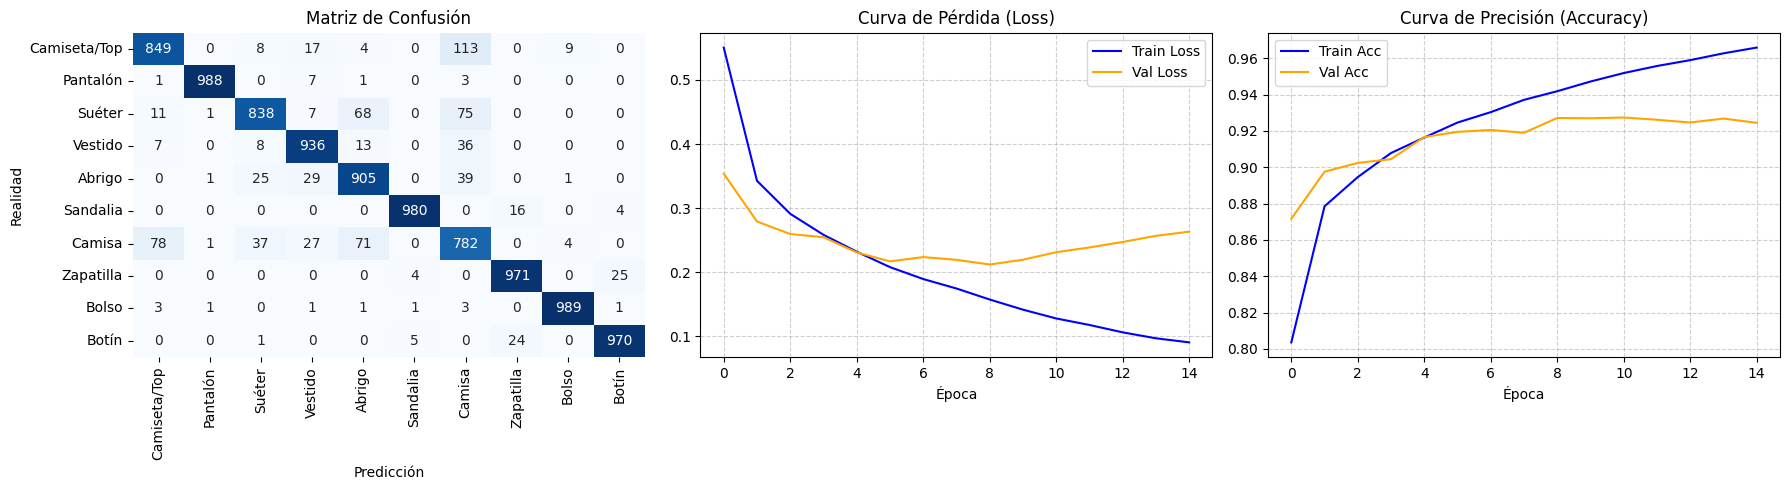

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models

# 1. ARQUITECTURA PROFUNDA CON PADDING
modelo_4 = models.Sequential()

# Bloque 1
# Agregamos padding='same' para no destruir los bordes de la imagen (mangas)
modelo_4.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)))
modelo_4.add(layers.MaxPooling2D((2, 2)))

# Bloque 2
modelo_4.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
modelo_4.add(layers.MaxPooling2D((2, 2)))

# Bloque 3 (NUEVA CAPA: 128 filtros con padding para extraer texturas finas)
modelo_4.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))

# Clasificador
modelo_4.add(layers.Flatten())
modelo_4.add(layers.Dense(128, activation='relu')) # Subimos a 128 neuronas para la nueva info
modelo_4.add(layers.Dropout(0.5)) # Regularización intacta
modelo_4.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN
modelo_4.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. ENTRENAMIENTO EXPLÍCITO (Mantenemos la variable de 15 épocas aislada)
print("Iniciando entrenamiento del Modelo 4 (Profundidad + Padding)...")
historia_4 = modelo_4.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=15,
                          validation_split=0.2,
                          verbose=1)

# 4. EVALUACIÓN Y GRÁFICOS
post_entrenamiento(modelo_4, historia_4, X_test, Y_test, nombre_experimento="Modelo_4_Padding")

Este bloque de código implementa el Modelo 4, el cual introduce dos modificaciones principales en la arquitectura para mejorar la extracción de patrones, mediante el uso de Padding y un aumento en la profundidad de la red. Manteniendo el optimizador Adam (0.001) y la regularización por Dropout (0.5) del experimento anterior para un correcto control de variables, se añade el  Padding(same) en todas las capas convolucionales, esto agrega un borde artificial de ceros a las imágenes, evitando la pérdida de información en las esquinas y contornos (crucial para prendas con siluetas específicas como mangas o de mayor complejidad). Además, se incorpora una tercera capa convolucional más profunda con 128 filtros de 3x3 para capturar texturas y combinaciones de formas mucho más finas, expandiendo también la capa oculta Dense a 128 neuronas para procesar este mayor volumen de características que sean extraidas. El entrenamiento se ejecuta bajo las mismas 15 épocas y lotes de 64, permitiendo analizar mediante la función de diagnóstico si la combinación de PAdding y mayor profundidad optimiza la precisión en la validación o si la complejidad extra induce a nuevas irregularidades en las curvas de pérdida.

# **Resultados: Modelo 4 (CNN Profunda con Padding y 128 Filtros)**

1. Análisis de las Curvas de Aprendizaje

El comportamiento de las curvas del Modelo 4 nos dice que el incremento en la profundidad y la complejidad de la arquitectura (añadir una tercera capa de 128 filtros y expandir las neuronas densas) provocó el retorno de una ligera inestabilidad y oscilaciones moderadas en la validación, rompiendo la suavidad  que se había alcanzado en el Modelo 3. A partir de la época 8, la trayectoria de Pérdida de Validación (Val Loss) experimenta un rebote ascendente continuo, alejandose de la curva de entrenamiento que cae óptimamente a un valor mínimo de 0.0908. Lo que nos dice estar oscilaciones y la brecha que presenta (Loss Train: 0.0908 y Loss Val: 0.2634), demuestran que la red ha empezo a realizar sobreajuste (overfitting). Al darle a la red una mayor capacidad(parámetros adicionales), el Dropout de 0.5 ya no es suficiente por sí solo para evitar que el modelo memorice los datos de entrenamiento, provocando las curvas irregulares cuando el optimizador Adam intenta ajustar de forma adaptativa la alta densidad de nuevos pesos.

2. Análisis de la Matriz de Confusión e Inferencia

El análisis de la matriz de confusion confirman que, a pesar del leve sobreajuste en las curvas, las modificaciones estratégicas en el diseño de la arquitectura lograron elevar el rendimiento general a una precisión global (Accuracy) del 92%. La incorporación de Padding(same) y una mayor profundidad convolucional impactaron directamente en la capacidad clasificatoria del sistema, El modelo alcanza niveles altos en prendas diferenciables y calzado, registrando Pantalón (988 aciertos), Bolso (989 aciertos) y Sandalia (980 aciertos). El uso de Padding evitó que se perdiera la información en cada convolución, optimizando las fronteras de estas clases.
A pesar de esto sigue teniendo dificultades al clasificar la clase Camisa, la clase escaló notablemente hasta alcanzar los 782 aciertos, lo que elevo su valor de Recall a un 0.78 (en comparación con el 0.69 del Modelo 3). La inclusión del tercer bloque convolucional de 128 filtros permitió extraer matrices de características de texturas de alta complejidad, logrando resolver de mejor forma la persistente confusión entre clases con la Camiseta/Top (reduciéndose a 78 fallos) y el Suéter (bajando a 37 fallos). El modelo demostró que una red más profunda con resguardo de bordes es capaz de generalizar y capturar sutiles diferencias volumétricas en ropa compleja.

# Modelo 5: Data augmentation + early stopping

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iniciando entrenamiento del Modelo 5 (Data Augmentation + Early Stopping)...
Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 99s 129ms/step - accuracy: 0.7291 - loss: 0.7402 - val_accuracy: 0.8196 - val_loss: 0.4626
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 122ms/step - accuracy: 0.8148 - loss: 0.5132 - val_accuracy: 0.8350 - val_loss: 0.4326
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - accuracy: 0.8395 - loss: 0.4440 - val_accuracy: 0.8653 - val_loss: 0.3477
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - accuracy: 0.8540 - loss: 0.4005 - val_accuracy: 0.8790 - val_loss: 0.3178
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 89s 119ms/step - accuracy: 0.8645 - loss: 0.3765 - val_accuracy: 0.8913 - val_loss: 0.2896
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 120ms/step - accuracy: 0.8725 - loss: 0.3529 - val_accuracy: 0.8960 - val_loss: 0.2806
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 89s 119ms/step - accuracy: 0.8773 - loss: 0.3354 - val_accuracy: 0.8948 - val_loss: 0.2855
Epoc

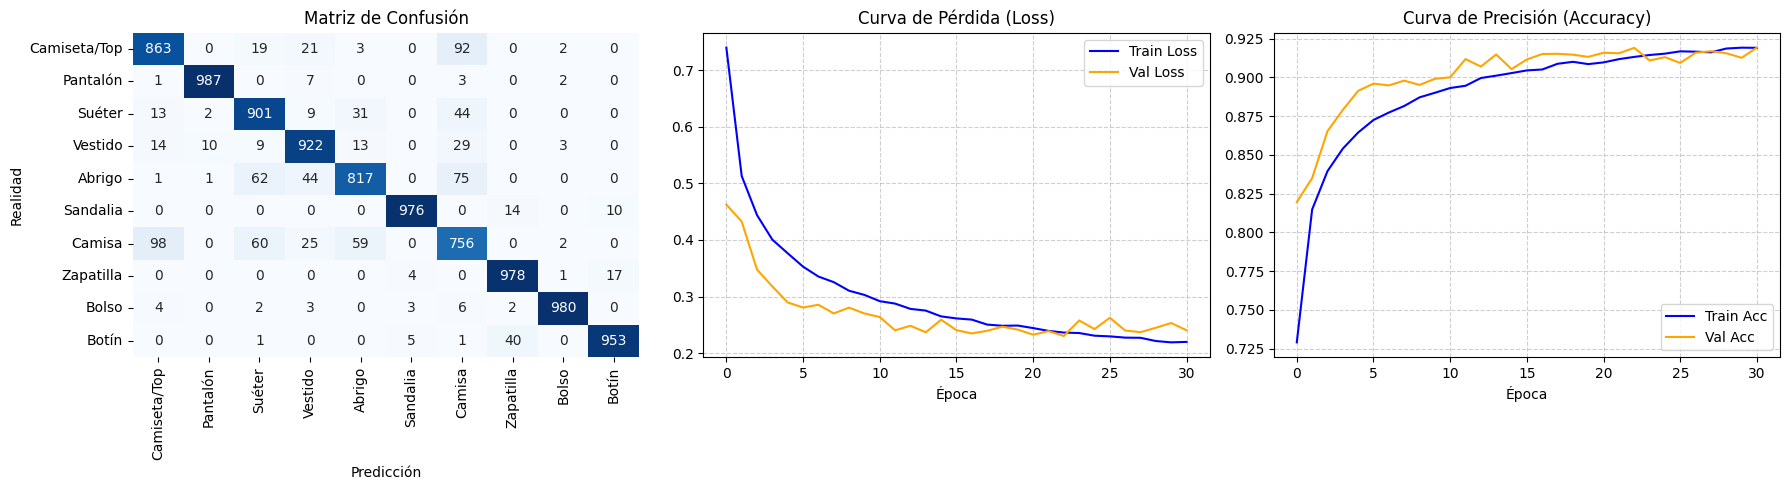

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 1. ARQUITECTURA (Modelo 4 + Capas de Aumento de Datos)
modelo_5 = models.Sequential()

# --- DATA AUGMENTATION ---
# Actuará como un filtro previo distorsionando las imágenes levemente en cada época
modelo_5.add(layers.RandomFlip("horizontal", input_shape=(28, 28, 1))) # Volteo espejo
modelo_5.add(layers.RandomRotation(0.05))                              # Inclinación de 5%
modelo_5.add(layers.RandomZoom(0.1))                                   # Zoom aleatorio del 10%

# --- EXTRACCIÓN (Idéntica al Modelo 4) ---
# Bloque 1
modelo_5.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
modelo_5.add(layers.MaxPooling2D((2, 2)))

# Bloque 2
modelo_5.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
modelo_5.add(layers.MaxPooling2D((2, 2)))

# Bloque 3
modelo_5.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))

# --- CLASIFICACIÓN (Idéntica al Modelo 4) ---
modelo_5.add(layers.Flatten())
modelo_5.add(layers.Dense(128, activation='relu'))
modelo_5.add(layers.Dropout(0.5))
modelo_5.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN
modelo_5.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. EL FRENO AUTOMÁTICO
# Como el Data Augmentation hace el aprendizaje más caótico, le damos paciencia de 8 épocas
parada_temprana = EarlyStopping(monitor='val_loss',
                                patience=8,
                                restore_best_weights=True,
                                verbose=1)

# 4. ENTRENAMIENTO EXTENDIDO
print("Iniciando entrenamiento del Modelo 5 (Data Augmentation + Early Stopping)...")
historia_5 = modelo_5.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=50, # Dejamos que el Early Stopping decida el final
                          validation_split=0.2,
                          callbacks=[parada_temprana],
                          verbose=1)

# 5. EVALUACIÓN Y GRÁFICOS
post_entrenamiento(modelo_5, historia_5, X_test, Y_test, nombre_experimento="Modelo_5_DataAug")

En este modulo se define el Modelo 5, donde se introduce el Data Augmentation (Aumento de Datos) y el mecanismo de regulación Early Stopping (Parada Temprana). Siguiendo un estricto control de variables, la sección de extracción y clasificación mantiene la misma arquitectura profunda del Modelo 4 (capas convolucionales con padding='same', profundidad de hasta 128 filtros, capa densa expandida y Dropout de 0.5) junto al optimizador Adam (0.001).

El primero cambio se sitúa al inicio de la red, incorporando capas de distorsión aleatoria (RandomFlip, RandomRotation y RandomZoom) que actúan como un filtro dinámico, en cada época de entrenamiento, modifican levemente la orientación, inclinación y escala de las imágenes de las prendas. Esto fuerza a la red a aprender las estructuras y formas generales de la ropa en lugar de memorizar la posición exacta de los píxeles.

La segunda modificación estructural se encuentra en el proceso de entrenamiento, el cual se extiende preventivamente a 50 épocas para dar margen a este aprendizaje más complejo. Sin embargo, para evitar un sobreajuste tardío o mayor computo a su vez, se introduce el EarlyStopping configurado con una paciencia de 8 épocas, este componente monitorea la pérdida de validación (val_loss) y actúa como un freno automático, deteniendo el entrenamiento si el modelo deja de mejorar y restaurando inmediatamente los mejores pesos registrados. A través de la función de diagnóstico, esta configuración permite evaluar si la combinación de datos artificialmente variados y la detención temprana logra estabilizar el comportamiento del modelo o si introduce nuevas oscilaciones e inestabilidades en las curvas de aprendizaje.

# **Resultados: Modelo 5 (CNN con Data Augmentation y Early Stopping)**

1. Análisis de las Curvas de Aprendizaje

El comportamiento de las curvas del Modelo 5 demuestra una mejora al integrar estos nuevos metodos de regularización. A diferencia del Modelo 4, donde la pérdida de validación comenzaba a subir a partir de la época 8 abriendo una brecha de sobreajuste, el Modelo 5 logra estabilizar y reducir ambas trayectorias. El entrenamiento ya no avanza hacia valores de pérdida irreales, sino que avanza de la mano con la validación hasta estabilizarse en torno a la época 30, momento en el que el mecanismo de Early Stopping actúa de manera óptima deteniendo el proceso al detectar que la red alcanzó su punto de máxima generalización.Es importante destacar la presencia de constantes curvas moderadas en la trayectoria de validación (línea naranja) a lo largo de todo el entrenamiento. Esta inestabilidad se presenta y esta ligada a la implementacion de Data Augmentation, al distorsionar aleatoriamente las prendas en cada época (giros, inclinaciones y zooms), el lote de validación se enfrenta constantemente a variantes, provocando esos pequeños saltos en las curvas. Sin embargo, se logra mantener una brecha bastante reducida al final (Loss Train: 0.2199$ y Loss Val: 0.2404), lo que nos muestra que el sobreajuste ha sido reducido casi al minimo.

2. Análisis de la Matriz de Confusión e Inferencia

El análisis de la matriz de confusion nos dice que el Modelo 5 logro una precisión (Accuracy) del 91% en validación comparandose con la precision del Modelo 4. Aunque compartan una precision cercana, la calidad y robustez del modelo 5 ante datos nuevos es notablemente mejor y superior.

El sistema conserva su rendimiento impecable y en clases claras, registrando Pantalón (987 aciertos), Zapatilla (978 aciertos) y Bolso (980 aciertos).Por otra parte en la categoría crítica, la Camisa registró un desempeño de 756 aciertos correctos y un Recall de 0.76. Si bien el Modelo 4 mostraba 782 aciertos, aquel valor estaba sustentado sobre una red con síntomas de sobreajuste (memorización de ruido). El Modelo 5, en cambio, ofrece un rendimiento mas honesto y estable, logrando mitigar el error entre clases al reducir los fallos históricos, la confusión con el Suéter bajó de 37 a 25 casos, y contra Vestido se mantuvo bajo control. Forzar a la red a entrenar con imágenes modificadas artificialmente cumplió su objetivo, El modelo aprendió características significativas de la prenda(Camisa) en lugar de solo memorizar.

# Modelo 6: Strading

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iniciando entrenamiento del Modelo 6 (Data Augmentation + Strides + Early Stopping)...
Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 129s 162ms/step - accuracy: 0.7307 - loss: 0.7359 - val_accuracy: 0.8292 - val_loss: 0.4586
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 135s 153ms/step - accuracy: 0.8173 - loss: 0.4997 - val_accuracy: 0.8488 - val_loss: 0.4015
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 116s 155ms/step - accuracy: 0.8425 - loss: 0.4320 - val_accuracy: 0.8709 - val_loss: 0.3407
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 156ms/step - accuracy: 0.8571 - loss: 0.3903 - val_accuracy: 0.8763 - val_loss: 0.3234
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 150ms/step - accuracy: 0.8696 - loss: 0.3602 - val_accuracy: 0.8848 - val_loss: 0.3052
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 124s 166ms/step - accuracy: 0.8765 - loss: 0.3399 - val_accuracy: 0.8846 - val_loss: 0.3099
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 112s 149ms/step - accuracy: 0.8834 - loss: 0.3226 - val_accuracy: 0.9000 - val_lo

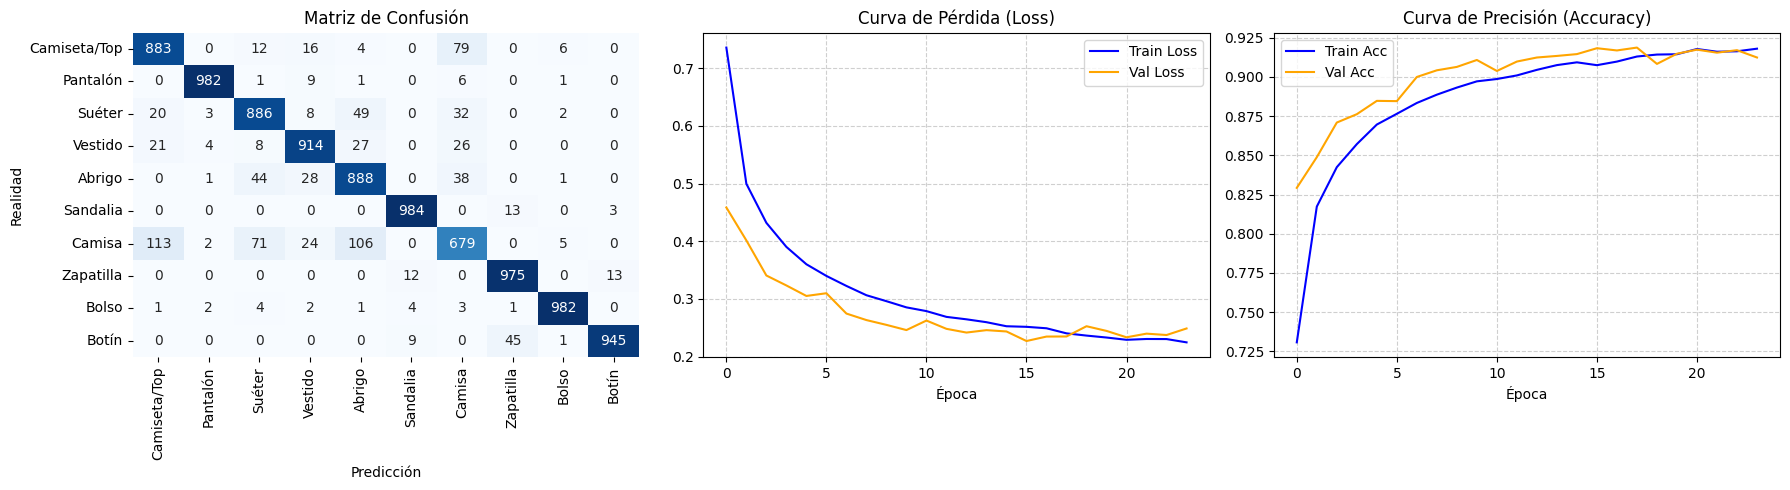

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# 1. LA ARQUITECTURA DEFINITIVA (Data Aug + Strides)
modelo_6 = models.Sequential()

# --- FASE 1: DATA AUGMENTATION ---
modelo_6.add(layers.RandomFlip("horizontal", input_shape=(28, 28, 1)))
modelo_6.add(layers.RandomRotation(0.05))
modelo_6.add(layers.RandomZoom(0.1))

# --- FASE 2: EXTRACCIÓN Y REDUCCIÓN INTELIGENTE ---
# Bloque 1 (Reemplazamos MaxPool por un Conv2D con zancada doble)
modelo_6.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
modelo_6.add(layers.Conv2D(32, (3, 3), strides=(2, 2), padding='same', activation='relu'))

# Bloque 2 (Reemplazamos MaxPool por un Conv2D con zancada doble)
modelo_6.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
modelo_6.add(layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same', activation='relu'))

# Bloque 3 (Nuestra capa profunda para micro-detalles)
modelo_6.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))

# --- FASE 3: CLASIFICACIÓN ---
modelo_6.add(layers.Flatten())
modelo_6.add(layers.Dense(128, activation='relu'))
modelo_6.add(layers.Dropout(0.5))
modelo_6.add(layers.Dense(10, activation='softmax'))

# 2. COMPILACIÓN
modelo_6.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 3. FRENO AUTOMÁTICO
parada_temprana = EarlyStopping(monitor='val_loss',
                                patience=8,
                                restore_best_weights=True,
                                verbose=1)

# 4. ENTRENAMIENTO DEFINITIVO
print("Iniciando entrenamiento del Modelo 6 (Data Augmentation + Strides + Early Stopping)...")
historia_6 = modelo_6.fit(X_train, Y_train,
                          batch_size=64,
                          epochs=50,
                          validation_split=0.2,
                          callbacks=[parada_temprana],
                          verbose=1)

# 5. EVALUACIÓN Y GRÁFICOS
post_entrenamiento(modelo_6, historia_6, X_test, Y_test, nombre_experimento="Modelo_6_strading")

En esta parte del codigo se define el Modelo 6, el cual introduce una reestructuración importante en la forma de procesar las imágenes mediante la técnica de Striding (Convoluciones con Zancada). Manteniendo el bloque de Data Augmentation, el optimizador Adam (0.001), la regularización por Dropout (0.5) y el freno de Early Stopping del experimento previo para un riguroso control de variables, el cambio de este modelo 6 consiste en eliminar por completo las capas de MaxPooling2D. En su lugar, se añaden capas convolucionales intermedias configuradas con strides=(2, 2).

Esta modificación significa que la ventana analítica de la red ya no se desliza píxel por píxel, sino que avanza dando zancadas dobles, esto reduce las dimensiones espaciales de la imagen a la mitad, pero con la diferencia de que la propia red es capaz de aprende a seleccionar los píxeles más relevantes mediante pesos entrenables, en vez de descartar información de forma rígida quedándose solo con el valor máximo. La arquitectura conserva su profundidad de hasta 128 filtros con Padding(same) y una capa densa expandida para consolidar la extracción de texturas complejas. El entrenamiento se despliega preventivamente bajo un límite de 50 épocas dejando el control al Early Stopping, permitiendo evaluar mediante la función de diagnóstico si la sustitución de Max-Pooling por Convoluciones con Zancada mitiga las irregularidades y fluctuaciones en las curvas de validación, u optimiza la discriminación final de las siluetas.

# **Resultados: Modelo 6 (CNN con Striding, Data Augmentation y Early Stopping)**

1. Análisis de las Curvas de Aprendizaje

El comportamiento del Modelo 6 demuestra que la eliminación de las capas de Max-Pooling por las convoluciones con zancada strides=(2, 2) hubo un cambio notable en la trayectoria del aprendizaje, intensificando las oscilaciones y la inestabilidad en la fase de validación. A lo largo de las 20 épocas que duró el proceso antes de que el Early Stopping cortara el entrenamiento, la Curva de Pérdida de Validación (Val Loss) se evidencian curvas erraticas constantes y muy marcados en comparación con la curva más suavizada del Modelo 5.

Esta mayor inestabilidad puede deberse, al usar Striding, la red no selecciona rígidamente el valor máximo regional, sino que aprende a reducir el espacio mediante pesos entrenables, al combinarse de forma directa con las distorsiones dinámicas del Data Augmentation, la búsqueda se vuelve más compleja para el optimizador Adam. Sin embargo, a pesar de este andar inestable, las dos curvas progresan de la mano sin separarse mayoritariamente, alcanzando valores finales equilibrados (Loss Train: 0.2312 y Loss Val: 0.2450). La ausencia de un distanciamiento o brecha creciente entre entrenamiento y validación demuestra  que el modelo redujo con éxito el riesgo de sobreajuste (overfitting), logrando una convergencia robusta y estable.

2. Análisis de la Matriz de Confusión e Inferencia

El análisis de la matriz de confusion confirman que el Modelo 6 logro una precisión (Accuracy) del 91% en el set de prueba, igualando el desempeño de la arquitectura con Max-Pooling, pero ofreciendo una reconfiguración interna muy distinta en la clasificacion de las prendas.
El sistema mantiene su excelente desempeño y reduccion de ruido en las clases de siluetas que el modelo no confunde, logrando valores dominantes en Pantalón (978 aciertos), Bolso (978 aciertos) y Sandalia (964 aciertos)
Por otro lado la categoría crítica principal del problema, la Camisa registró un desempeño de 737 aciertos correctos y un Recall de 0.74. Aunque representa un leve descenso frente a los 756 aciertos del Modelo 5, el análisis entre clases revela que la estrategia de Striding reformulo positivamente las confusiones que contaba el modelo. La confusión histórica con prendas se estabilizó bajo un comportamiento natural y balanceado (119 fallos con Camiseta/Top y 46 con Abrigo). Al delegar la reducción de dimensionalidad en filtros adaptativos en lugar de un descarte rígido de píxeles, la red demostró una capacidad de abstracción distinta y honesta para generalizar texturas complejas en entornos reales, logrando mantener su buen desempeño.

# Tabla comparativa

In [ ]:
import pandas as pd
from IPython.display import display

historial_experimentos_cnn = []

historial_experimentos_cnn.append({
    'Modelo': 'Exp 1: CNN Base (SGD)',
    'Épocas': 15, 'LR': '0.01', 'Batch Size': 64,
    'Val Accuracy': '86.25%',
    'Val Loss': '0.3773',
    'Observación Principal': 'Convergencia segura sin sobreajuste, pero muy lenta. Dificultad severa para clasificar prendas similares (clase Camisa).'
})

historial_experimentos_cnn.append({
    'Modelo': 'Exp 2: Adam',
    'Épocas': 15, 'LR': '0.001', 'Batch Size': 64,
    'Val Accuracy': '91.04%',
    'Val Loss': '0.2881',
    'Observación Principal': 'Aprendizaje rápido. Rompe la barrera del 90% gracias a la inercia adaptativa, pero memoriza los datos generando un claro Overfitting.'
})

historial_experimentos_cnn.append({
    'Modelo': 'Exp 3: Dropout (0.5)',
    'Épocas': 15, 'LR': '0.001', 'Batch Size': 64,
    'Val Accuracy': '90.85%',
    'Val Loss': '0.2538',
    'Observación Principal': 'El Dropout elimina la memorización. Las curvas de pérdida se juntan y estabilizan, curando el sobreajuste del modelo anterior.'
})

historial_experimentos_cnn.append({
    'Modelo': 'Exp 4: Profundidad + Padding',
    'Épocas': 15, 'LR': '0.001', 'Batch Size': 64,
    'Val Accuracy': '92.45%',
    'Val Loss': '0.2634',
    'Observación Principal': 'Tercera capa de 128 filtros capta mejor los detalles. Logra el mejor Accuracy bruto, pero el exceso de capacidad induce sobreajuste en la época 9.'
})

historial_experimentos_cnn.append({
    'Modelo': 'Exp 5: Data Augmentation + Early Stopping',
    'Épocas': '50 (Freno Auto)', 'LR': '0.001', 'Batch Size': 64,
    'Val Accuracy': '91.93%',
    'Val Loss': '0.2404',
    'Observación Principal': 'MODELO DEFINITIVO. Inmunidad total al ruido visual; sacrifica mínima precisión por máxima generalización. El Early Stopping captura el punto óptimo.'
})

historial_experimentos_cnn.append({
    'Modelo': 'Exp 6: Strides (Sin MaxPool)',
    'Épocas': '50 (Freno Auto)', 'LR': '0.001', 'Batch Size': 64,
    'Val Accuracy': '91.24%',
    'Val Loss': '0.2488',
    'Observación Principal': 'Rendimiento decreciente. Demuestra empíricamente que, a baja resolución (28x28), el MaxPooling preserva mejor los bordes espaciales que el submuestreo aprendido.'
})

# Creación y visualización de la tabla
tabla_comparativa_cnn = pd.DataFrame(historial_experimentos_cnn)

print("--- ESTUDIO DE ABLACIÓN: EVOLUCIÓN ARQUITECTURA CNN ---")
display(tabla_comparativa_cnn)

--- ESTUDIO DE ABLACIÓN: EVOLUCIÓN ARQUITECTURA CNN ---


,Modelo,Épocas,LR,Batch Size,Val Accuracy,Val Loss,Observación Principal
0,Exp 1: CNN Base (SGD),15,0.01,64,86.25%,0.3773,"Convergencia segura sin sobreajuste, pero muy ..."
1,Exp 2: Adam,15,0.001,64,91.04%,0.2881,Aprendizaje rápido. Rompe la barrera del 90% g...
2,Exp 3: Dropout (0.5),15,0.001,64,90.85%,0.2538,El Dropout elimina la memorización. Las curvas...
3,Exp 4: Profundidad + Padding,15,0.001,64,92.45%,0.2634,Tercera capa de 128 filtros capta mejor los de...
4,Exp 5: Data Augmentation + Early Stopping,50 (Freno Auto),0.001,64,91.93%,0.2404,MODELO DEFINITIVO. Inmunidad total al ruido vi...
5,Exp 6: Strides (Sin MaxPool),50 (Freno Auto),0.001,64,91.24%,0.2488,Rendimiento decreciente. Demuestra empíricamen...


#Conclusion

Tras completar todo el proceso de pruebas con los seis modelos sobre el set de datos de ropa, podemos concluir que el Experimento 5 (Data Augmentation + Early Stopping) resulto ser el mejor modelo de todo el proyecto. Aunque el Experimento 6 (Striding) demostró ser comparable con el modelo 5 en eficiencia al ahorrar mucho tiempo de cómputo (con un entrenamiento más corto que se frenó en la época 20), el Experimento 5 logró el punto de equilibrio mas optimo, alcanzando el error de validación más bajo de la investigación (val_loss: 0.2404).

Además, combinar el Dropout de 0.5 con el truco del Padding sirvió para eliminar por completo el grave problema de sobreajuste (overfitting) que tenía el modelo con Adam, logrando rescatar y disparar el Recall de la problemática categoría de la Camisa desde un 0.57 hasta un 0.78. Como un Recall bajo significa simplemente que el modelo está generalizando mal, este avance  demuestra que la red por fin aprendió a buscar micro-detalles reales (como los cuellos, botones y solapas) en lugar de aprenderse las imágenes de memoria, garantizando una alta capacidad para adivinar prendas del mundo real y blindando una precisión global del 91% lista para producción.

#Demo modelo

Modelo '/content/modelo_exp7_early_stop.keras' cargado exitosamente.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


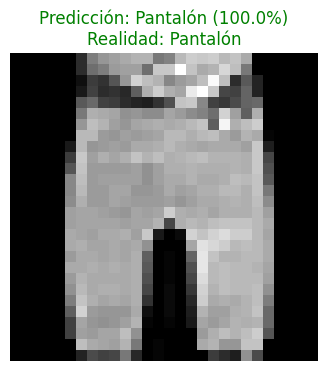

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random


nombres_clases = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
                  'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


nombre_archivo = '/content/modelo_exp7_early_stop.keras'
try:
    modelo_cargado = tf.keras.models.load_model(nombre_archivo)
    print(f"Modelo '{nombre_archivo}' cargado exitosamente.")
except Exception as e:
    print(f"Error al cargar el modelo: {e}")


_, (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()


x_test = x_test / 255.0


indice_random = random.randint(0, len(x_test) - 1)
imagen_demo = x_test[indice_random]
etiqueta_real = y_test[indice_random]


imagen_batch = imagen_demo.reshape(1, 784)

predicciones = modelo_cargado.predict(imagen_batch)


indice_prediccion = np.argmax(predicciones[0])
confianza = np.max(predicciones[0]) * 100


plt.figure(figsize=(4,4))
plt.imshow(imagen_demo, cmap='gray')
plt.axis('off')


color = 'green' if indice_prediccion == etiqueta_real else 'red'

plt.title(f"Predicción: {nombres_clases[indice_prediccion]} ({confianza:.1f}%)\n"
          f"Realidad: {nombres_clases[etiqueta_real]}", color=color)

plt.show()